In [81]:
import pandas as pd

df = pd.read_csv("../data/processed/amazon_clean.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (270343, 7)

Columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']


In [82]:
print(df["inbound"].value_counts())

inbound
False    169840
True     100503
Name: count, dtype: int64


In [83]:
customers = df[df["inbound"] == True].copy()

print("Customer messages:", len(customers))

Customer messages: 100503


In [84]:
customers[["tweet_id", "created_at", "text"]].head(20)

,tweet_id,created_at,text
1,648406,2015-06-13 02:17:56+00:00,@AmazonHelp here this on my gift card activity...
3,369261,2015-06-26 23:30:09+00:00,@AmazonHelp Here's why it matters: I need veri...
5,369260,2015-06-27 05:07:00+00:00,@AmazonHelp That's exactly what she did. Bough...
7,369263,2015-06-27 16:54:26+00:00,@AmazonHelp Can she delete her review &amp; re...
9,130746,2015-07-17 15:01:06+00:00,@115850 @AmazonHelp ur __email__ seems not wor...
13,1087360,2016-03-20 19:06:54+00:00,@amazonhelp No i have not recived any email li...
15,1087355,2016-03-22 05:06:27+00:00,@AmazonHelp I have share my details
17,1087354,2016-03-23 05:30:43+00:00,@amazonhelp what the hell you guys are doing
21,313819,2016-05-06 15:20:12+00:00,@amazonhelp seller already received package be...
23,313816,2016-05-06 15:57:59+00:00,@amazonhelp I already A2Z claims 2 times on se...


In [85]:
customers[["created_at", "text"]].sample(
    30,
    random_state=42
)

,created_at,text
226662,2017-11-26 10:35:45+00:00,@AmazonHelp Específicamente para estos pedidos...
180836,2017-11-15 03:04:00+00:00,@AmazonHelp AMZL US
268100,2017-12-03 12:13:06+00:00,"@AmazonHelp Damn bots, I HAVE TOLD YOU THIS A ..."
4497,2017-10-04 18:39:15+00:00,"@AmazonHelp ""Please follow bellow instructions..."
216958,2017-11-24 09:41:59+00:00,@AmazonHelp Yes - The Echo Dot is discovering ...
53285,2017-10-14 14:55:40+00:00,"@AmazonHelp I called customer care, they said ..."
74134,2017-10-19 06:44:18+00:00,@AmazonHelp Anyways.. the only option I have t...
217731,2017-11-24 12:21:39+00:00,@AmazonHelp Ok Guys. leave it any how I had be...
51257,2017-10-14 07:25:05+00:00,@AmazonHelp I have an idea. I will use the Dat...
85767,2017-10-21 23:47:47+00:00,@AmazonHelp So today I got this notification.....


In [86]:
top_messages = (
    customers["text"]
    .value_counts()
    .head(30)
)

top_messages

text
@AmazonHelp Yes                 159
@AmazonHelp Done                130
@AmazonHelp Thank you           128
@AmazonHelp Thanks              125
@AmazonHelp Thank you!           98
@AmazonHelp Ok                   89
@AmazonHelp No                   89
@AmazonHelp AMZL US              89
@AmazonHelp Thanks!              76
@AmazonHelp Done.                69
@AmazonHelp USPS                 65
@AmazonHelp Thank you.           60
@AmazonHelp Yes.                 41
@AmazonHelp Amazon               38
@AmazonHelp Merci                31
@AmazonHelp Thanks.              31
@AmazonHelp .com                 31
@AmazonHelp UPS                  30
@AmazonHelp Gracias              27
@AmazonHelp ありがとうございます！          26
@AmazonHelp Ok thanks            24
@AmazonHelp Done!                24
@AmazonHelp done                 23
@AmazonHelp ありがとうございます           22
@AmazonHelp No.                  21
@AmazonHelp Oui                  20
@AmazonHelp yes                  20
@AmazonHelp Sent       

In [87]:
from collections import Counter
import re

text = " ".join(customers["text"].astype(str).tolist()).lower()

words = re.findall(r"\b[a-z]{3,}\b", text)

word_counts = Counter(words)

word_counts.most_common(50)

[('amazonhelp', 102111),
 ('the', 45959),
 ('and', 25534),
 ('you', 21501),
 ('for', 17316),
 ('have', 15632),
 ('that', 15570),
 ('not', 15485),
 ('was', 13491),
 ('this', 13009),
 ('but', 12124),
 ('amazon', 12012),
 ('your', 9255),
 ('can', 8317),
 ('https', 8083),
 ('with', 8070),
 ('order', 7945),
 ('delivery', 7577),
 ('just', 7541),
 ('now', 7193),
 ('they', 7099),
 ('will', 7075),
 ('from', 6560),
 ('que', 5895),
 ('been', 5673),
 ('get', 5648),
 ('are', 5522),
 ('what', 5359),
 ('time', 5209),
 ('all', 5011),
 ('thanks', 4778),
 ('email', 4743),
 ('customer', 4734),
 ('today', 4719),
 ('prime', 4677),
 ('still', 4550),
 ('one', 4368),
 ('don', 4328),
 ('when', 4304),
 ('service', 4299),
 ('there', 4262),
 ('already', 4187),
 ('has', 4126),
 ('delivered', 4115),
 ('out', 3948),
 ('yes', 3858),
 ('day', 3827),
 ('why', 3642),
 ('help', 3580),
 ('days', 3402)]

In [88]:
keywords = [
    "refund",
    "delivery",
    "package",
    "order",
    "payment",
    "cancel",
    "account",
    "password",
    "return",
    "charge",
    "shipping",
    "prime"
]

for keyword in keywords:
    count = customers["text"].str.lower().str.contains(
        keyword,
        regex=False,
        na=False
    ).sum()

    print(f"{keyword:10} : {count}")

refund     : 3372
delivery   : 6677
package    : 2611
order      : 10500
payment    : 491
cancel     : 2467
account    : 2782
password   : 299
return     : 2019
charge     : 998
shipping   : 1486
prime      : 4639


In [89]:
refund_messages = customers[
    customers["text"]
    .str.lower()
    .str.contains("refund", regex=False, na=False)
]

print("Refund-related messages:", len(refund_messages))

refund_messages[["created_at", "text"]].sample(
    min(30, len(refund_messages)),
    random_state=42
)

Refund-related messages: 3372


,created_at,text
259011,2017-12-01 18:22:09+00:00,@AmazonHelp Sure! Two items in a pack arrived ...
78047,2017-10-20 05:46:16+00:00,@AmazonHelp Your correspondence does NOT addre...
145356,2017-11-05 02:42:57+00:00,@AmazonHelp I haven't got any refund ...😈 http...
10282,2017-10-05 21:06:57+00:00,@AmazonHelp I am looking for replacement/refun...
144578,2017-11-04 20:10:28+00:00,@AmazonHelp Thanks for quick Action refund is ...
46569,2017-10-13 07:21:47+00:00,@AmazonHelp They said Amazon has no options to...
182895,2017-11-15 14:21:27+00:00,@AmazonHelp and take a day off to facilitate t...
4603,2017-10-04 18:56:32+00:00,@AmazonHelp Make it happen on 5-10-2017 and re...
16589,2017-10-07 05:49:08+00:00,@AmazonHelp Please check I have filled the for...
184057,2017-11-15 19:40:36+00:00,"@AmazonHelp It states what I was asking there,..."


In [90]:
intent_definitions = {
    "order_status": "Customer wants to know the current status or location of an order.",
    
    "delivery_issue": "Customer reports a delayed, failed, missing, or incorrectly delivered package.",
    
    "refund_issue": "Customer asks about requesting, receiving, tracking, or correcting a refund.",
    
    "return_replacement": "Customer wants to return an item or receive a replacement.",
    
    "order_cancellation": "Customer wants to cancel an order or asks about an order cancellation.",
    
    "payment_billing": "Customer has a payment, charge, billing, or transaction problem.",
    
    "account_access": "Customer has an account, login, password, or account-related problem.",
    
    "prime_membership": "Customer has a problem or question related to Amazon Prime or Prime membership.",
    
    "other_support": "A genuine customer support request that does not fit the other intents."
}

for intent, definition in intent_definitions.items():
    print(f"{intent}:")
    print(f"  {definition}\n")

order_status:
  Customer wants to know the current status or location of an order.

delivery_issue:
  Customer reports a delayed, failed, missing, or incorrectly delivered package.

refund_issue:
  Customer asks about requesting, receiving, tracking, or correcting a refund.

return_replacement:
  Customer wants to return an item or receive a replacement.

order_cancellation:
  Customer wants to cancel an order or asks about an order cancellation.

payment_billing:
  Customer has a payment, charge, billing, or transaction problem.

account_access:
  Customer has an account, login, password, or account-related problem.

prime_membership:
  Customer has a problem or question related to Amazon Prime or Prime membership.

other_support:
  A genuine customer support request that does not fit the other intents.



In [91]:
intent_examples = {
    "order_status": [
        "Where is my order?",
        "Can you tell me where my package is?",
        "What's the status of my order?"
    ],
    
    "delivery_issue": [
        "My package is late.",
        "It says delivered but I never received it.",
        "My delivery was supposed to arrive yesterday."
    ],
    
    "refund_issue": [
        "Where is my refund?",
        "I still haven't received my refund.",
        "When will I get my money back?"
    ],
    
    "return_replacement": [
        "I want to return this item.",
        "How can I return my order?",
        "Can I get a replacement?"
    ],
    
    "order_cancellation": [
        "I want to cancel my order.",
        "Please cancel my order.",
        "Why was my order cancelled?"
    ],
    
    "payment_billing": [
        "My payment failed.",
        "Why was I charged twice?",
        "There is an incorrect charge on my account."
    ],
    
    "account_access": [
        "I can't log into my account.",
        "I forgot my password.",
        "I have a problem with my account."
    ],
    
    "prime_membership": [
        "My Prime membership isn't working.",
        "I have a problem with my Prime subscription.",
        "Why can't I use my Prime benefits?"
    ],
    
    "other_support": [
        "I need help with something else.",
        "I have a problem with my Amazon account.",
        "Can someone help me with this issue?"
    ]
}

for intent, examples in intent_examples.items():
    print(f"\n{intent}")
    for example in examples:
        print(f"  - {example}")


order_status
  - Where is my order?
  - Can you tell me where my package is?
  - What's the status of my order?

delivery_issue
  - My package is late.
  - It says delivered but I never received it.
  - My delivery was supposed to arrive yesterday.

refund_issue
  - Where is my refund?
  - I still haven't received my refund.
  - When will I get my money back?

return_replacement
  - I want to return this item.
  - How can I return my order?
  - Can I get a replacement?

order_cancellation
  - I want to cancel my order.
  - Please cancel my order.
  - Why was my order cancelled?

payment_billing
  - My payment failed.
  - Why was I charged twice?
  - There is an incorrect charge on my account.

account_access
  - I can't log into my account.
  - I forgot my password.
  - I have a problem with my account.

prime_membership
  - My Prime membership isn't working.
  - I have a problem with my Prime subscription.
  - Why can't I use my Prime benefits?

other_support
  - I need help with som

In [92]:
intent_keywords = {
    "order_status": ["order", "track"],
    "delivery_issue": ["delivery", "delivered", "package", "arrive", "late"],
    "refund_issue": ["refund", "money back", "reimburse"],
    "return_replacement": ["return", "replacement", "replace"],
    "order_cancellation": ["cancel", "cancelled", "canceled"],
    "payment_billing": ["payment", "charged", "charge", "billing"],
    "account_access": ["account", "password", "login", "sign in"],
    "prime_membership": ["prime", "membership", "subscription"],
}

In [93]:
acknowledgements = {
    "yes",
    "yes.",
    "no",
    "no.",
    "ok",
    "ok.",
    "okay",
    "okay.",
    "thanks",
    "thanks!",
    "thanks.",
    "thank you",
    "thank you!",
    "thank you.",
    "done",
    "done!",
    "done.",
    "sent",
    "merci",
    "gracias",
    "oui"
}

def is_substantive(text):
    text = str(text).strip()
    
    cleaned = text.lower().replace("@amazonhelp", "").strip()
    cleaned = cleaned.strip(" .,!?:;-")
    
    if len(cleaned) < 15:
        return False
    
    if cleaned in acknowledgements:
        return False
    
    return True


customers["is_substantive"] = customers["text"].apply(is_substantive)

substantive = customers[customers["is_substantive"]].copy()

print("Total customer messages:", len(customers))
print("Substantive messages:", len(substantive))
print("Filtered messages:", len(customers) - len(substantive))

Total customer messages: 100503
Substantive messages: 93458
Filtered messages: 7045


In [94]:
for intent, keywords in intent_keywords.items():
    pattern = "|".join(
        keyword.replace(" ", r"\s+")
        for keyword in keywords
    )
    
    matches = substantive[
        substantive["text"]
        .str.lower()
        .str.contains(pattern, regex=True, na=False)
    ]
    
    print("\n" + "=" * 70)
    print(f"{intent} — {len(matches)} candidate messages")
    print("=" * 70)
    
    sample = matches[["text"]].sample(
        min(10, len(matches)),
        random_state=42
    )
    
    for message in sample["text"]:
        print("-", message)


order_status — 11717 candidate messages
- @AmazonHelp Have visited your link, too much fussandbother to get into it. Your delivey was lousy.nuff said. Black mark. Will stop ordering if this becomes the norm.
- @AmazonHelp Black Friday shouldn't play any part in this delay. I ordered it 5 days ago. One day delay fine but 5 days ? Come on!
- @AmazonHelp @366906 Hi I ordered one item but have been sent two of the exact same and charged twice. Pls advise how to fix
- @AmazonHelp Already done that. Can’t you guys see my tweets?? Another order is undelivered as of today.
- @AmazonHelp @AmazonHelp Order placed on 27 morning for same day delivery. Expectation: will be delivered on same day. Initial Tracking status: Will be delivered on 27. At midnight, new tracking status: Will be delivered on 28th. What's the point of same day delivery?
- @AmazonHelp My orders would never come via FedEx. The latest Amazon guy told me that they can’t ban carriers. Not happy about being lied to twice!
- @Amazo

In [95]:
import pandas as pd

candidate_keywords = [
    "order",
    "delivery",
    "package",
    "refund",
    "return",
    "replacement",
    "cancel",
    "payment",
    "charge",
    "billing",
    "account",
    "password",
    "login",
    "prime"
]

pattern = "|".join(
    keyword.replace(" ", r"\s+")
    for keyword in candidate_keywords
)

candidate_pool = substantive[
    substantive["text"]
    .str.lower()
    .str.contains(pattern, regex=True, na=False)
].copy()

print("Substantive messages:", len(substantive))
print("Candidate pool:", len(candidate_pool))

Substantive messages: 93458
Candidate pool: 27879


In [96]:
candidate_pool = candidate_pool.drop_duplicates(
    subset=["text"]
).copy()

print("Unique candidate messages:", len(candidate_pool))

Unique candidate messages: 27847


In [97]:
labeling_sample = candidate_pool.sample(
    min(2000, len(candidate_pool)),
    random_state=42
).copy()

print("Messages selected for labeling:", len(labeling_sample))

Messages selected for labeling: 2000


In [98]:
labeling_sample["intent"] = ""
labeling_sample["label_notes"] = ""

labeling_sample = labeling_sample[
    [
        "tweet_id",
        "created_at",
        "text",
        "intent",
        "label_notes"
    ]
].copy()

labeling_sample.head()

,tweet_id,created_at,text,intent,label_notes
205481,2798334,2017-11-21 23:30:52+00:00,@AmazonHelp Then why does it say when you’re s...,,
122001,2533521,2017-10-30 12:47:58+00:00,@AmazonHelp A seller but thru Amazon. Having p...,,
213319,686709,2017-11-23 14:17:53+00:00,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",,
110403,1255701,2017-10-27 13:02:28+00:00,@AmazonHelp Thank you for providing extremely ...,,
50656,963281,2017-10-14 04:09:46+00:00,@AmazonHelp Yes. It took over 30 minutes. No I...,,


In [99]:
labeling_sample.to_csv(
    "../data/processed/amazon_labeling_sample.csv",
    index=False
)

print("Saved labeling file.")

Saved labeling file.


In [100]:
labeled = pd.read_csv(
    "../data/processed/amazon_labeling_sample.csv"
)

print(labeled.shape)
print(labeled.columns.tolist())

(2000, 5)
['tweet_id', 'created_at', 'text', 'intent', 'label_notes']


In [101]:
labeled["intent"].value_counts(dropna=False)

intent
NaN    2000
Name: count, dtype: int64

In [102]:
first_100 = labeled.head(100)

print(
    first_100["intent"]
    .value_counts(dropna=False)
)

intent
NaN    100
Name: count, dtype: int64


In [103]:
empty_labels = first_100[
    first_100["intent"].isna() |
    (first_100["intent"].fillna("").astype(str).str.strip() == "")
]

print("Unlabeled rows:", len(empty_labels))

Unlabeled rows: 100


In [104]:
for intent in first_100["intent"].dropna().unique():
    print("\n" + "=" * 70)
    print(intent)
    print("=" * 70)

    examples = first_100[
        first_100["intent"] == intent
    ][["text", "label_notes"]].head(5)

    for _, row in examples.iterrows():
        print("TEXT:", row["text"])
        print("NOTE:", row["label_notes"])
        print()

In [105]:
label_counts = first_100["intent"].value_counts()

print(label_counts)

Series([], Name: count, dtype: int64)


In [106]:
label_percentages = (
    first_100["intent"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(label_percentages)

Series([], Name: proportion, dtype: float64)


In [107]:
for intent in sorted(first_100["intent"].dropna().unique()):
    print("\n" + "=" * 80)
    print(intent)
    print("=" * 80)

    examples = first_100[
        first_100["intent"] == intent
    ][["text", "label_notes"]]

    for _, row in examples.head(5).iterrows():
        print("TEXT:", row["text"])
        print("NOTE:", row["label_notes"])
        print()

In [108]:
expected_intents = set(intent_definitions.keys())

observed_intents = set(
    first_100["intent"].dropna().unique()
)

missing_intents = expected_intents - observed_intents

print("Missing intents:", missing_intents)

Missing intents: {'return_replacement', 'delivery_issue', 'other_support', 'account_access', 'refund_issue', 'order_status', 'payment_billing', 'prime_membership', 'order_cancellation'}


In [109]:
first_100.to_csv(
    "../data/processed/amazon_labeled_100.csv",
    index=False
)

print("Saved:", len(first_100), "labeled examples")

Saved: 100 labeled examples


In [110]:
labeled_100 = pd.read_csv(
    "../data/processed/amazon_labeled_100.csv"
)

print("Rows:", len(labeled_100))
print("\nIntent distribution:")
print(labeled_100["intent"].value_counts())

Rows: 100

Intent distribution:
Series([], Name: count, dtype: int64)


In [111]:
training_seed = labeled_100[
    ["text", "intent"]
].copy()

training_seed = training_seed.dropna(
    subset=["text", "intent"]
)

training_seed["text"] = training_seed["text"].astype(str).str.strip()
training_seed["intent"] = training_seed["intent"].astype(str).str.strip()

print("Training seed:", len(training_seed))

Training seed: 0


In [112]:
conflicts = (
    training_seed
    .groupby("text")["intent"]
    .nunique()
)

conflicting_texts = conflicts[conflicts > 1]

print("Conflicting messages:", len(conflicting_texts))

Conflicting messages: 0


In [113]:
training_seed.to_csv(
    "../data/processed/training_seed.csv",
    index=False
)

print("Saved training seed:", len(training_seed))

Saved training seed: 0


In [114]:
training_seed["intent"].value_counts()

Series([], Name: count, dtype: int64)

In [115]:
print("Conflicting messages:", len(conflicting_texts))

Conflicting messages: 0


In [116]:
print("training_seed rows:", len(training_seed))
print("\nIntent values:")
print(training_seed["intent"].head(20).tolist())

print("\nNumber of non-empty intents:")
print(
    training_seed["intent"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
    .sum()
)

training_seed rows: 0

Intent values:
[]

Number of non-empty intents:
0


In [117]:
labeling_check = pd.read_csv(
    "../data/processed/amazon_labeling_sample.csv"
)

print("Rows:", len(labeling_check))

print("\nIntent distribution:")
print(
    labeling_check["intent"]
    .fillna("")
    .astype(str)
    .str.strip()
    .value_counts()
)

print("\nFirst 10 rows:")
labeling_check[["text", "intent"]].head(10)

Rows: 2000

Intent distribution:
intent
    2000
Name: count, dtype: int64

First 10 rows:


,text,intent
0,@AmazonHelp Then why does it say when you’re s...,NaN
1,@AmazonHelp A seller but thru Amazon. Having p...,NaN
2,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",NaN
3,@AmazonHelp Thank you for providing extremely ...,NaN
4,@AmazonHelp Yes. It took over 30 minutes. No I...,NaN
5,@AmazonHelp Ya lo resolví. Cancelé pedido y vo...,NaN
6,"@AmazonHelp Il s'agit de la poste, j'ai un num...",NaN
7,@AmazonHelp The last communication I had was w...,NaN
8,@AmazonHelp Added new payment method (corporat...,NaN
9,@AmazonHelp Hi DC. Looks like the return is to...,NaN


In [118]:
labeling_check = pd.read_csv(
    "../data/processed/amazon_labeling_sample.csv"
)

first_100 = labeling_check.head(100)

print("Rows:", len(first_100))

print("\nIntent distribution:")
print(first_100["intent"].value_counts(dropna=False))

Rows: 100

Intent distribution:
intent
NaN    100
Name: count, dtype: int64


In [119]:
empty_labels = first_100[
    first_100["intent"].isna() |
    (first_100["intent"].fillna("").astype(str).str.strip() == "")
]

print("Unlabeled rows:", len(empty_labels))

Unlabeled rows: 100


In [120]:
labeling_100 = labeling_check.head(100).copy()

labeling_100.to_csv(
    "../data/processed/amazon_labeling_100.csv",
    index=False
)

print("Created:", len(labeling_100), "messages")

Created: 100 messages


In [121]:
intents = {
    "order_status": "Questions about order status, tracking, or when an order is expected.",
    
    "delivery_issue": "Problems with delivery such as delays, failed delivery, missing package, wrong delivery status, or carrier problems.",
    
    "delivery_address_options": "Requests or problems related to delivery address, delivery location, delivery time, or delivery options.",
    
    "order_cancellation": "Requests or problems related to cancelling an order.",
    
    "return_replacement": "Requests or problems related to returning an item or getting a replacement.",
    
    "refund": "Questions or problems related to refunds, including refund status, missing refunds, or refund amount.",
    
    "product_issue": "Problems with the received product, such as wrong, damaged, defective, missing, or poor-quality items.",
    
    "payment_billing": "Problems or questions about payments, charges, billing, cards, financing, or transaction amounts.",
    
    "account_access": "Problems with Amazon account access, login, password, account blocking, or account settings.",
    
    "prime_membership": "Questions or problems related to Amazon Prime membership, benefits, subscription, or Prime-specific services.",
    
    "seller_marketplace": "Problems specifically involving third-party sellers or marketplace orders.",
    
    "product_availability_pricing": "Questions about product availability, release dates, pre-orders, prices, discounts, or promotions.",
    
    "installation_service": "Problems involving installation, appointments, or other scheduled Amazon services.",
    
    "other_support": "A genuine Amazon support request that does not clearly fit another intent."
}

for name, description in intents.items():
    print(f"{name}: {description}")

order_status: Questions about order status, tracking, or when an order is expected.
delivery_issue: Problems with delivery such as delays, failed delivery, missing package, wrong delivery status, or carrier problems.
delivery_address_options: Requests or problems related to delivery address, delivery location, delivery time, or delivery options.
order_cancellation: Requests or problems related to cancelling an order.
return_replacement: Requests or problems related to returning an item or getting a replacement.
refund: Questions or problems related to refunds, including refund status, missing refunds, or refund amount.
product_issue: Problems with the received product, such as wrong, damaged, defective, missing, or poor-quality items.
payment_billing: Problems or questions about payments, charges, billing, cards, financing, or transaction amounts.
account_access: Problems with Amazon account access, login, password, account blocking, or account settings.
prime_membership: Questions or 

In [122]:
import pandas as pd

labeling_df = pd.read_csv(
    "../data/processed/amazon_labeling_100.csv"
)

print("Number of messages:", len(labeling_df))
print(labeling_df.columns.tolist())

Number of messages: 100
['tweet_id', 'created_at', 'text', 'intent', 'label_notes']


In [123]:
# Create a numbered view for manual labeling

labeling_view = labeling_df[["tweet_id", "text", "intent", "label_notes"]].copy()

labeling_view.insert(
    0,
    "row_number",
    range(1, len(labeling_view) + 1)
)

display(labeling_view)

,row_number,tweet_id,text,intent,label_notes
0,1,2798334,@AmazonHelp Then why does it say when you’re s...,NaN,NaN
1,2,2533521,@AmazonHelp A seller but thru Amazon. Having p...,NaN,NaN
2,3,686709,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",NaN,NaN
3,4,1255701,@AmazonHelp Thank you for providing extremely ...,NaN,NaN
4,5,963281,@AmazonHelp Yes. It took over 30 minutes. No I...,NaN,NaN
...,...,...,...,...,...
95,96,461357,@AmazonHelp well now it's saying sometime befo...,NaN,NaN
96,97,1310948,@AmazonHelp Last order ONE item was NOT as des...,NaN,NaN
97,98,524228,@AmazonHelp What is the purpose of having amaz...,NaN,NaN
98,99,926334,@AmazonHelp There is no enabled option. Like I...,NaN,NaN


In [124]:
def show_batch(start, end):
    batch = labeling_df.iloc[start:end]

    for index, row in batch.iterrows():
        print("=" * 80)
        print(f"ROW: {index + 1}")
        print(f"TWEET ID: {row['tweet_id']}")
        print(f"MESSAGE: {row['text']}")
        print()

In [125]:
show_batch(0, 10)

ROW: 1
TWEET ID: 2798334
MESSAGE: @AmazonHelp Then why does it say when you’re shopping “want it by Wednesday 11/22? Order in the next 2 hours!” That seems pretty simple to understand and I am always within those parameters.

ROW: 2
TWEET ID: 2533521
MESSAGE: @AmazonHelp A seller but thru Amazon. Having probs logging into account at min to contact them.

ROW: 3
TWEET ID: 686709
MESSAGE: @AmazonHelp Ordered the red 8" 16gb about 15 minutes ago (with a few other things)! Thanks :) It will be here Saturday. Now how do I keep it a secret until Christmas ? That's a bigger question. Ha ha 😂

ROW: 4
TWEET ID: 1255701
MESSAGE: @AmazonHelp Thank you for providing extremely late delivery with wrong product size and poor quality.

ROW: 5
TWEET ID: 963281
MESSAGE: @AmazonHelp Yes. It took over 30 minutes. No I was already upset so I wanted it canceled right away.

ROW: 6
TWEET ID: 1263384
MESSAGE: @AmazonHelp Ya lo resolví. Cancelé pedido y volví a realizarlo porque me confundí en un dato de la di

In [126]:
labels_1_10 = [
    "order_status",
    "account_access",
    "order_status",
    "product_issue",
    "order_cancellation",
    "delivery_address_options",
    "delivery_issue",
    "delivery_address_options",
    "payment_billing",
    "return_replacement"
]

notes_1_10 = [
    "Customer is questioning the promised delivery date.",
    "Customer cannot log into the account.",
    "Customer is discussing the expected delivery date.",
    "Customer received the wrong size and poor-quality product.",
    "Customer wanted the order cancelled.",
    "Customer cancelled and reordered because of incorrect address information.",
    "Customer has a tracking/carrier support problem.",
    "Customer requested a specific delivery time.",
    "Customer accidentally used a corporate card for a personal purchase.",
    "Customer is discussing the return destination."
]

labeling_df.loc[0:9, "intent"] = labels_1_10
labeling_df.loc[0:9, "label_notes"] = notes_1_10

display(
    labeling_df.loc[
        0:9,
        ["tweet_id", "text", "intent", "label_notes"]
    ]
)

C:\Users\sujat\AppData\Local\Temp\ipykernel_6256\301973599.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['order_status', 'account_access', 'order_status', 'product_issue', 'order_cancellation', 'delivery_address_options', 'delivery_issue', 'delivery_address_options', 'payment_billing', 'return_replacement']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  labeling_df.loc[0:9, "intent"] = labels_1_10
C:\Users\sujat\AppData\Local\Temp\ipykernel_6256\301973599.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['Customer is questioning the promised delivery date.', 'Customer cannot log into the account.', 'Customer is discussing the expected delivery date.', 'Customer received the wrong size and poor-quality product.', 'Customer wanted the order cancelled.', 'Customer cance

,tweet_id,text,intent,label_notes
0,2798334,@AmazonHelp Then why does it say when you’re s...,order_status,Customer is questioning the promised delivery ...
1,2533521,@AmazonHelp A seller but thru Amazon. Having p...,account_access,Customer cannot log into the account.
2,686709,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",order_status,Customer is discussing the expected delivery d...
3,1255701,@AmazonHelp Thank you for providing extremely ...,product_issue,Customer received the wrong size and poor-qual...
4,963281,@AmazonHelp Yes. It took over 30 minutes. No I...,order_cancellation,Customer wanted the order cancelled.
5,1263384,@AmazonHelp Ya lo resolví. Cancelé pedido y vo...,delivery_address_options,Customer cancelled and reordered because of in...
6,2394456,"@AmazonHelp Il s'agit de la poste, j'ai un num...",delivery_issue,Customer has a tracking/carrier support problem.
7,2931921,@AmazonHelp The last communication I had was w...,delivery_address_options,Customer requested a specific delivery time.
8,775352,@AmazonHelp Added new payment method (corporat...,payment_billing,Customer accidentally used a corporate card fo...
9,31306,@AmazonHelp Hi DC. Looks like the return is to...,return_replacement,Customer is discussing the return destination.


In [127]:
# Make the labeling columns explicitly string-compatible
labeling_df["intent"] = labeling_df["intent"].astype("string")
labeling_df["label_notes"] = labeling_df["label_notes"].astype("string")

print("Labeling columns converted to string type.")

print("\nRows labeled:", labeling_df["intent"].notna().sum())
print("Rows remaining:", labeling_df["intent"].isna().sum())

Labeling columns converted to string type.

Rows labeled: 10
Rows remaining: 90


In [128]:
labels_11_20 = [
    "return_replacement",
    "seller_marketplace",
    "prime_membership",
    "prime_membership",
    "account_access",
    "product_availability_pricing",
    "delivery_address_options",
    "other_support",
    "order_status",
    "delivery_issue"
]

notes_11_20 = [
    "Customer is discussing the return destination.",
    "Customer has a problem involving a product sold through Amazon.",
    "Customer is complaining about the Prime two-day delivery expectation.",
    "Customer is asking about Prime Movies.",
    "Customer's message concerns a blocked Amazon account.",
    "Customer asks why certain Nintendo games are unavailable for release-day delivery.",
    "Customer has a constraint related to package pickup timing.",
    "Customer states that they ordered through a link but gives no specific support problem.",
    "Customer discusses the shipping status of current and previous orders.",
    "Customer's package was marked lost and other items were delayed."
]

labeling_df.loc[10:19, "intent"] = labels_11_20
labeling_df.loc[10:19, "label_notes"] = notes_11_20

display(
    labeling_df.loc[
        10:19,
        ["tweet_id", "text", "intent", "label_notes"]
    ]
)

,tweet_id,text,intent,label_notes
10,73640,@AmazonHelp i sold my product on ur site..the ...,return_replacement,Customer is discussing the return destination.
11,1227296,"@AmazonHelp From marketing and past service, c...",seller_marketplace,Customer has a problem involving a product sol...
12,2229747,"@AmazonHelp Ah ok, the distinction being purch...",prime_membership,Customer is complaining about the Prime two-da...
13,2940175,@AmazonHelp No I didn't receive any mail regar...,prime_membership,Customer is asking about Prime Movies.
14,476839,@AmazonHelp That just states postal codes. I'v...,account_access,Customer's message concerns a blocked Amazon a...
15,2863361,"@AmazonHelp I am aware, however my apartment o...",product_availability_pricing,Customer asks why certain Nintendo games are u...
16,2460294,@AmazonHelp Hi Az i ordered via https://t.co/h...,delivery_address_options,Customer has a constraint related to package p...
17,671261,@AmazonHelp My current order ended up shipping...,other_support,Customer states that they ordered through a li...
18,2613309,@AmazonHelp First time I was told the package ...,order_status,Customer discusses the shipping status of curr...
19,2858115,@AmazonHelp No. Helpfully the app is just sayi...,delivery_issue,Customer's package was marked lost and other i...


In [129]:
print("Rows labeled:", labeling_df["intent"].notna().sum())
print("Rows remaining:", labeling_df["intent"].isna().sum())

Rows labeled: 20
Rows remaining: 80


In [130]:
labels_21_30 = [
    "order_status",
    "delivery_issue",
    "order_cancellation",
    "delivery_issue",
    "delivery_issue",
    "delivery_issue",
    "product_availability_pricing",
    "product_availability_pricing",
    "other_support",
    "order_cancellation"
]

notes_21_30 = [
    "Customer is checking the expected delivery status.",
    "Customer is complaining about the Amazon Delivery carrier.",
    "Customer cancelled the order after the delivery date moved.",
    "Customer discusses delivery authentication before marking an item delivered.",
    "Customer says carriers incorrectly mark packages as delivered and miss guaranteed dates.",
    "Customer says packages are not being delivered on time.",
    "Customer's main complaint is the price drop and need to reorder to get the lower price.",
    "Customer is concerned about delivery updates for a pre-ordered limited item.",
    "Customer is making a general complaint about customer service.",
    "Customer requested cancellation but the cancellation process initially failed."
]

labeling_df.loc[20:29, "intent"] = labels_21_30
labeling_df.loc[20:29, "label_notes"] = notes_21_30

display(
    labeling_df.loc[
        20:29,
        ["tweet_id", "text", "intent", "label_notes"]
    ]
)

,tweet_id,text,intent,label_notes
20,412320,@AmazonHelp AMAZON DELIVERY. I literally dread...,order_status,Customer is checking the expected delivery sta...
21,1147830,@AmazonHelp I canceled my order today after th...,delivery_issue,Customer is complaining about the Amazon Deliv...
22,419464,@AmazonHelp Received replacement. TY I would r...,order_cancellation,Customer cancelled the order after the deliver...
23,2137935,"@AmazonHelp yes, UPS but particularly USPS. Th...",delivery_issue,Customer discusses delivery authentication bef...
24,1447952,@AmazonHelp Yes. They said they’ll deliver whe...,delivery_issue,Customer says carriers incorrectly mark packag...
25,140973,@AmazonHelp And now the price has dropped by £...,delivery_issue,Customer says packages are not being delivered...
26,2686032,"@AmazonHelp Yup, figured as much - just worrie...",product_availability_pricing,Customer's main complaint is the price drop an...
27,181208,@AmazonHelp But my (desperate) complaint is th...,product_availability_pricing,Customer is concerned about delivery updates f...
28,345100,@AmazonHelp I requested a cancellation on an o...,other_support,Customer is making a general complaint about c...
29,502585,@AmazonHelp The feedback is that I can’t remem...,order_cancellation,Customer requested cancellation but the cancel...


In [131]:
print("Rows labeled:", labeling_df["intent"].notna().sum())
print("Rows remaining:", labeling_df["intent"].isna().sum())

Rows labeled: 30
Rows remaining: 70


In [132]:
# Labels for rows 31-100

labels_31_100 = [
    # 31-40
    "delivery_issue",
    "refund",
    "delivery_issue",
    "prime_membership",
    "delivery_issue",
    "delivery_issue",
    "other_support",
    "delivery_issue",
    "return_replacement",
    "payment_billing",

    # 41-50
    "payment_billing",
    "account_access",
    "product_availability_pricing",
    "delivery_issue",
    "delivery_issue",
    "delivery_issue",
    "account_access",
    "payment_billing",
    "other_support",
    "payment_billing",

    # 51-60
    "return_replacement",
    "delivery_issue",
    "account_access",
    "product_availability_pricing",
    "prime_membership",
    "prime_membership",
    "return_replacement",
    "delivery_issue",
    "order_status",
    "refund",

    # 61-70
    "prime_membership",
    "delivery_issue",
    "refund",
    "delivery_issue",
    "refund",
    "delivery_issue",
    "account_access",
    "account_access",
    "payment_billing",
    "prime_membership",

    # 71-80
    "delivery_address_options",
    "return_replacement",
    "delivery_issue",
    "delivery_issue",
    "return_replacement",
    "return_replacement",
    "delivery_issue",
    "product_issue",
    "prime_membership",
    "delivery_address_options",

    # 81-90
    "prime_membership",
    "delivery_issue",
    "refund",
    "delivery_issue",
    "refund",
    "delivery_issue",
    "account_access",
    "account_access",
    "payment_billing",
    "prime_membership",

    # 91-100
    "delivery_address_options",
    "return_replacement",
    "delivery_issue",
    "delivery_issue",
    "return_replacement",
    "return_replacement",
    "prime_membership",
    "product_issue",
    "prime_membership",
    "delivery_issue"
]

# Apply labels to rows 31-100
labeling_df.loc[30:99, "intent"] = labels_31_100

print("Rows labeled:", labeling_df["intent"].notna().sum())
print("Rows remaining:", labeling_df["intent"].isna().sum())

Rows labeled: 100
Rows remaining: 0


In [133]:
check_df = pd.read_csv(
    "../data/processed/amazon_labeling_100.csv"
)

print("Rows:", len(check_df))
print("Unlabeled:", check_df["intent"].isna().sum())

display(
    check_df[
        ["tweet_id", "text", "intent"]
    ].head(10)
)

Rows: 100
Unlabeled: 100


,tweet_id,text,intent
0,2798334,@AmazonHelp Then why does it say when you’re s...,NaN
1,2533521,@AmazonHelp A seller but thru Amazon. Having p...,NaN
2,686709,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",NaN
3,1255701,@AmazonHelp Thank you for providing extremely ...,NaN
4,963281,@AmazonHelp Yes. It took over 30 minutes. No I...,NaN
5,1263384,@AmazonHelp Ya lo resolví. Cancelé pedido y vo...,NaN
6,2394456,"@AmazonHelp Il s'agit de la poste, j'ai un num...",NaN
7,2931921,@AmazonHelp The last communication I had was w...,NaN
8,775352,@AmazonHelp Added new payment method (corporat...,NaN
9,31306,@AmazonHelp Hi DC. Looks like the return is to...,NaN


In [134]:
print("Rows:", len(labeling_df))
print("Labeled in memory:", labeling_df["intent"].notna().sum())
print("Unlabeled in memory:", labeling_df["intent"].isna().sum())

display(
    labeling_df[["tweet_id", "text", "intent"]].head(10)
)

Rows: 100
Labeled in memory: 100
Unlabeled in memory: 0


,tweet_id,text,intent
0,2798334,@AmazonHelp Then why does it say when you’re s...,order_status
1,2533521,@AmazonHelp A seller but thru Amazon. Having p...,account_access
2,686709,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",order_status
3,1255701,@AmazonHelp Thank you for providing extremely ...,product_issue
4,963281,@AmazonHelp Yes. It took over 30 minutes. No I...,order_cancellation
5,1263384,@AmazonHelp Ya lo resolví. Cancelé pedido y vo...,delivery_address_options
6,2394456,"@AmazonHelp Il s'agit de la poste, j'ai un num...",delivery_issue
7,2931921,@AmazonHelp The last communication I had was w...,delivery_address_options
8,775352,@AmazonHelp Added new payment method (corporat...,payment_billing
9,31306,@AmazonHelp Hi DC. Looks like the return is to...,return_replacement


In [135]:
# Save the labeled dataframe
labeling_df.to_csv(
    "../data/processed/amazon_labeling_100.csv",
    index=False
)

# Read it back from disk to verify the actual saved file
saved_df = pd.read_csv(
    "../data/processed/amazon_labeling_100.csv"
)

print("Rows:", len(saved_df))
print("Unlabeled:", saved_df["intent"].isna().sum())

print("\nIntent distribution:")
print(saved_df["intent"].value_counts())

display(
    saved_df[["tweet_id", "text", "intent"]].head(10)
)

Rows: 100
Unlabeled: 0

Intent distribution:
intent
delivery_issue                  28
prime_membership                12
return_replacement              11
account_access                   9
payment_billing                  7
refund                           6
delivery_address_options         6
order_status                     5
product_availability_pricing     5
other_support                    4
product_issue                    3
order_cancellation               3
seller_marketplace               1
Name: count, dtype: int64


,tweet_id,text,intent
0,2798334,@AmazonHelp Then why does it say when you’re s...,order_status
1,2533521,@AmazonHelp A seller but thru Amazon. Having p...,account_access
2,686709,"@AmazonHelp Ordered the red 8"" 16gb about 15 m...",order_status
3,1255701,@AmazonHelp Thank you for providing extremely ...,product_issue
4,963281,@AmazonHelp Yes. It took over 30 minutes. No I...,order_cancellation
5,1263384,@AmazonHelp Ya lo resolví. Cancelé pedido y vo...,delivery_address_options
6,2394456,"@AmazonHelp Il s'agit de la poste, j'ai un num...",delivery_issue
7,2931921,@AmazonHelp The last communication I had was w...,delivery_address_options
8,775352,@AmazonHelp Added new payment method (corporat...,payment_billing
9,31306,@AmazonHelp Hi DC. Looks like the return is to...,return_replacement


In [136]:
import pandas as pd

df_labeled = pd.read_csv(
    "../data/processed/amazon_labeling_100.csv"
)

print("Dataset shape:", df_labeled.shape)
print("\nColumns:")
print(df_labeled.columns.tolist())

print("\nIntent distribution:")
print(df_labeled["intent"].value_counts())

Dataset shape: (100, 5)

Columns:
['tweet_id', 'created_at', 'text', 'intent', 'label_notes']

Intent distribution:
intent
delivery_issue                  28
prime_membership                12
return_replacement              11
account_access                   9
payment_billing                  7
refund                           6
delivery_address_options         6
order_status                     5
product_availability_pricing     5
other_support                    4
product_issue                    3
order_cancellation               3
seller_marketplace               1
Name: count, dtype: int64


In [137]:
# Identify intents with very few examples

intent_counts = df_labeled["intent"].value_counts()

print("Intent counts:\n")
print(intent_counts)

print("\nIntents with fewer than 3 examples:")
print(intent_counts[intent_counts < 3])

Intent counts:

intent
delivery_issue                  28
prime_membership                12
return_replacement              11
account_access                   9
payment_billing                  7
refund                           6
delivery_address_options         6
order_status                     5
product_availability_pricing     5
other_support                    4
product_issue                    3
order_cancellation               3
seller_marketplace               1
Name: count, dtype: int64

Intents with fewer than 3 examples:
intent
seller_marketplace    1
Name: count, dtype: int64


In [138]:
# Keep only intents with at least 3 examples
# for the initial baseline experiment.

min_examples = 3

valid_intents = (
    df_labeled["intent"]
    .value_counts()
    .loc[lambda x: x >= min_examples]
    .index
)

baseline_df = df_labeled[
    df_labeled["intent"].isin(valid_intents)
].copy()

print("Original dataset:", len(df_labeled))
print("Baseline dataset:", len(baseline_df))
print("Excluded rows:", len(df_labeled) - len(baseline_df))

print("\nBaseline intent distribution:")
print(baseline_df["intent"].value_counts())

Original dataset: 100
Baseline dataset: 99
Excluded rows: 1

Baseline intent distribution:
intent
delivery_issue                  28
prime_membership                12
return_replacement              11
account_access                   9
payment_billing                  7
delivery_address_options         6
refund                           6
order_status                     5
product_availability_pricing     5
other_support                    4
order_cancellation               3
product_issue                    3
Name: count, dtype: int64


In [139]:
from sklearn.model_selection import train_test_split

X = baseline_df["text"]
y = baseline_df["intent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

print("\nTraining intent distribution:")
print(y_train.value_counts())

print("\nTest intent distribution:")
print(y_test.value_counts())

Training samples: 79
Test samples: 20

Training intent distribution:
intent
delivery_issue                  22
prime_membership                10
return_replacement               9
account_access                   7
payment_billing                  6
refund                           5
delivery_address_options         5
order_status                     4
product_availability_pricing     4
other_support                    3
product_issue                    2
order_cancellation               2
Name: count, dtype: int64

Test intent distribution:
intent
delivery_issue                  6
account_access                  2
prime_membership                2
return_replacement              2
product_availability_pricing    1
order_cancellation              1
delivery_address_options        1
product_issue                   1
payment_billing                 1
refund                          1
order_status                    1
other_support                   1
Name: count, dtype: int64


In [140]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [141]:
y_pred = baseline_model.predict(X_test)

print("Predictions generated:", len(y_pred))

print("\nFirst 10 predictions:")
for text, actual, predicted in zip(
    X_test.iloc[:10],
    y_test.iloc[:10],
    y_pred[:10]
):
    print("\nMessage:", text)
    print("Actual:   ", actual)
    print("Predicted:", predicted)

Predictions generated: 20

First 10 predictions:

Message: @AmazonHelp And now the price has dropped by £50, but on chat they say the only way to get this price is to re-order it? Is this really true, I've got to mess around canceling and reordering, and yet another delay in my order arriving https://t.co/VJeFHUOY9r
Actual:    delivery_issue
Predicted: account_access

Message: @AmazonHelp Yes. It took over 30 minutes. No I was already upset so I wanted it canceled right away.
Actual:    order_cancellation
Predicted: payment_billing

Message: @AmazonHelp Escalated it to a supervisor and he managed to help fix the issue stating that Account had Australia Regional setting that was causing the issue, Video is working on laptop, iPad and Mobile now, @132976 still shows unavailable :(
Actual:    account_access
Predicted: prime_membership

Message: @AmazonHelp Yup, figured as much - just worried when folks who pre-ordered after me were getting delivery updates for a limited item kind of thing

In [142]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [143]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Macro metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Baseline Model Performance")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")

print("\nDetailed Classification Report")
print("=" * 40)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Baseline Model Performance
Accuracy : 0.1000
Macro Precision: 0.0375
Macro Recall   : 0.0556
Macro F1       : 0.0429

Detailed Classification Report
                              precision    recall  f1-score   support

              account_access       0.00      0.00      0.00         2
    delivery_address_options       0.00      0.00      0.00         1
              delivery_issue       0.20      0.17      0.18         6
          order_cancellation       0.00      0.00      0.00         1
                order_status       0.00      0.00      0.00         1
               other_support       0.00      0.00      0.00         1
             payment_billing       0.00      0.00      0.00         1
            prime_membership       0.00      0.00      0.00         2
product_availability_pricing       0.00      0.00      0.00         1
               product_issue       0.00      0.00      0.00         1
                      refund       0.00      0.00      0.00         1
          

In [144]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Baseline Model Performance")
print("=" * 40)

print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")

print("\nDetailed Classification Report")
print("=" * 40)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Baseline Model Performance
Accuracy       : 0.1000
Macro Precision: 0.0375
Macro Recall   : 0.0556
Macro F1       : 0.0429

Detailed Classification Report
                              precision    recall  f1-score   support

              account_access       0.00      0.00      0.00         2
    delivery_address_options       0.00      0.00      0.00         1
              delivery_issue       0.20      0.17      0.18         6
          order_cancellation       0.00      0.00      0.00         1
                order_status       0.00      0.00      0.00         1
               other_support       0.00      0.00      0.00         1
             payment_billing       0.00      0.00      0.00         1
            prime_membership       0.00      0.00      0.00         2
product_availability_pricing       0.00      0.00      0.00         1
               product_issue       0.00      0.00      0.00         1
                      refund       0.00      0.00      0.00         1
    

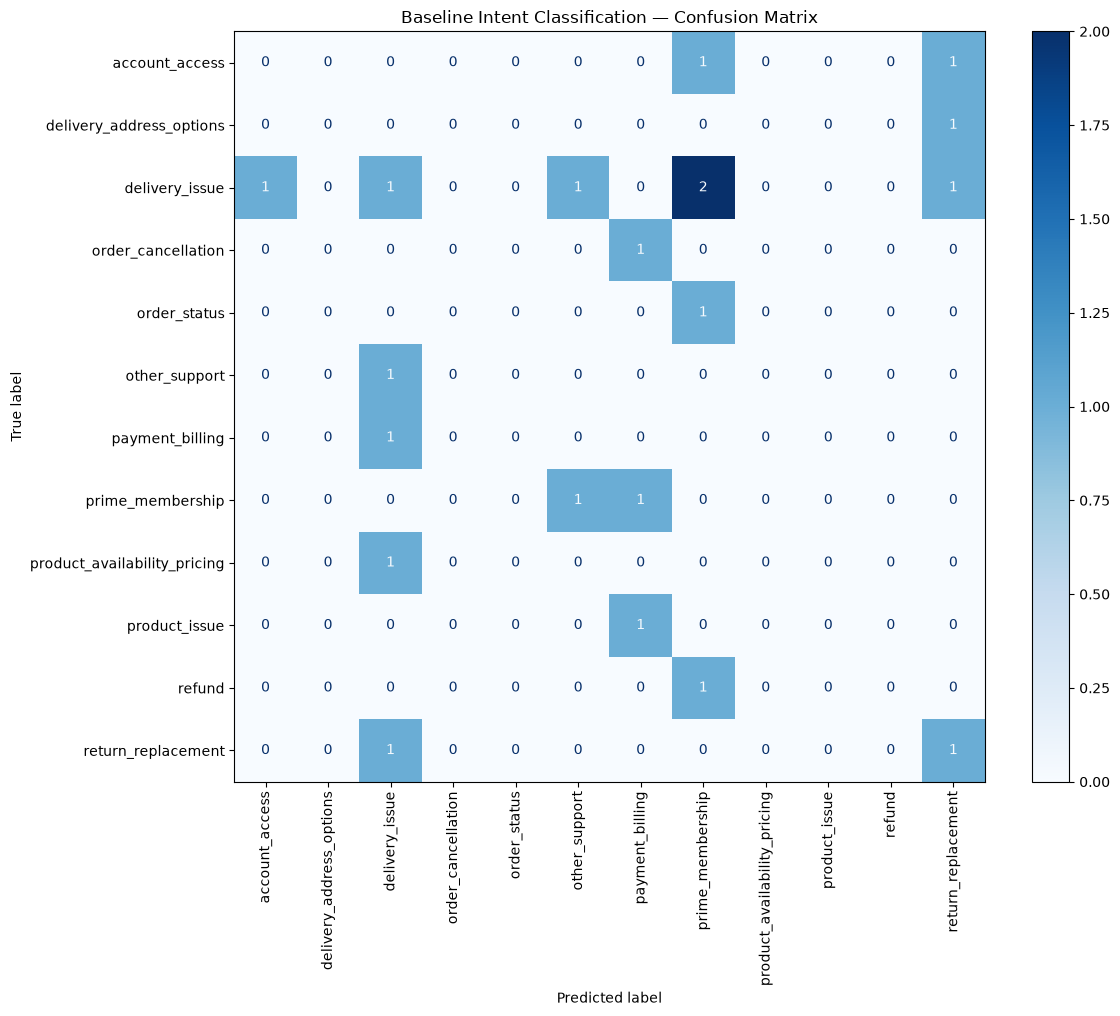

In [145]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Baseline Intent Classification — Confusion Matrix")
plt.tight_layout()
plt.show()

In [146]:
# Show all test predictions for error analysis

results = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

results["correct"] = results["actual"] == results["predicted"]

display(results)

,text,actual,predicted,correct
0,@AmazonHelp And now the price has dropped by £...,delivery_issue,account_access,False
1,@AmazonHelp Yes. It took over 30 minutes. No I...,order_cancellation,payment_billing,False
2,@AmazonHelp Escalated it to a supervisor and h...,account_access,prime_membership,False
3,"@AmazonHelp Yup, figured as much - just worrie...",product_availability_pricing,delivery_issue,False
4,@AmazonHelp No. Helpfully the app is just sayi...,delivery_issue,prime_membership,False
5,@AmazonHelp Order status hasn't changed &amp; ...,delivery_issue,other_support,False
6,"@AmazonHelp Not yet no, I only ordered it in t...",product_issue,payment_billing,False
7,@AmazonHelp A year of prime membership gratis ...,delivery_address_options,return_replacement,False
8,@AmazonHelp i sold my product on ur site..the ...,return_replacement,delivery_issue,False
9,@AmazonHelp There is some date they are saying...,delivery_issue,prime_membership,False


In [147]:
# Show only incorrect predictions

errors = results[results["correct"] == False].copy()

print(f"Total test examples: {len(results)}")
print(f"Correct predictions: {results['correct'].sum()}")
print(f"Incorrect predictions: {len(errors)}")

display(errors[["text", "actual", "predicted"]])

Total test examples: 20
Correct predictions: 2
Incorrect predictions: 18


,text,actual,predicted
0,@AmazonHelp And now the price has dropped by £...,delivery_issue,account_access
1,@AmazonHelp Yes. It took over 30 minutes. No I...,order_cancellation,payment_billing
2,@AmazonHelp Escalated it to a supervisor and h...,account_access,prime_membership
3,"@AmazonHelp Yup, figured as much - just worrie...",product_availability_pricing,delivery_issue
4,@AmazonHelp No. Helpfully the app is just sayi...,delivery_issue,prime_membership
5,@AmazonHelp Order status hasn't changed &amp; ...,delivery_issue,other_support
6,"@AmazonHelp Not yet no, I only ordered it in t...",product_issue,payment_billing
7,@AmazonHelp A year of prime membership gratis ...,delivery_address_options,return_replacement
8,@AmazonHelp i sold my product on ur site..the ...,return_replacement,delivery_issue
9,@AmazonHelp There is some date they are saying...,delivery_issue,prime_membership


In [148]:
# Step 10.1 - Create candidate pool for expanded labeling

import pandas as pd

# Load the complete cleaned Amazon customer-support dataset
amazon_df = pd.read_csv("../data/processed/amazon_clean.csv")

# Keep customer messages only
customer_df = amazon_df[
    amazon_df["inbound"] == True
].copy()

# Load the 100 messages that have already been manually labeled
labeled_df = pd.read_csv(
    "../data/processed/amazon_labeling_100.csv"
)

# Remove already-labeled tweets
candidate_df = customer_df[
    ~customer_df["tweet_id"].isin(labeled_df["tweet_id"])
].copy()

print("Total customer messages:", len(customer_df))
print("Already labeled:", len(labeled_df))
print("Available unlabeled messages:", len(candidate_df))

Total customer messages: 100503
Already labeled: 100
Available unlabeled messages: 100403


In [149]:
# Keywords used only to find potentially useful candidates.
# They do NOT determine the final intent label.

keyword_groups = {
    "seller_marketplace": [
        "seller",
        "marketplace",
        "third party",
        "third-party",
        "sold my",
        "seller central"
    ],

    "order_cancellation": [
        "cancel order",
        "cancel my order",
        "cancelled order",
        "canceled order",
        "want to cancel",
        "need to cancel"
    ],

    "product_issue": [
        "damaged",
        "broken",
        "defective",
        "wrong item",
        "wrong product",
        "missing item",
        "not working"
    ],

    "account_access": [
        "password",
        "login",
        "log in",
        "locked out",
        "account",
        "sign in"
    ],

    "payment_billing": [
        "charged",
        "charge",
        "billing",
        "payment",
        "credit card",
        "debit card",
        "card charged"
    ],

    "refund": [
        "refund",
        "refunded",
        "money back",
        "refund status"
    ],

    "return_replacement": [
        "return",
        "replacement",
        "replace",
        "exchange"
    ],

    "product_availability_pricing": [
        "price",
        "pricing",
        "discount",
        "available",
        "availability",
        "pre-order",
        "preorder"
    ],

    "prime_membership": [
        "prime",
        "prime membership",
        "prime video",
        "prime subscription"
    ],

    "delivery_address_options": [
        "address",
        "delivery address",
        "change address",
        "delivery time",
        "delivery location"
    ],

    "order_status": [
        "order status",
        "tracking",
        "track my order",
        "where is my order",
        "when will my order"
    ],

    "delivery_issue": [
        "late",
        "delayed",
        "delivery",
        "delivered",
        "package",
        "parcel",
        "carrier",
        "courier",
        "not arrived"
    ]
}

# Collect candidates from each keyword group
targeted_parts = []

text_lower = candidate_df["text"].fillna("").str.lower()

for intent, keywords in keyword_groups.items():

    mask = False

    for keyword in keywords:
        mask = mask | text_lower.str.contains(
            keyword,
            regex=False,
            na=False
        )

    matches = candidate_df[mask].copy()

    # Take up to 100 candidates from each group
    matches = matches.sample(
        n=min(100, len(matches)),
        random_state=42
    )

    matches["candidate_source"] = intent

    targeted_parts.append(matches)

targeted_candidates = pd.concat(
    targeted_parts,
    ignore_index=True
)

# Remove duplicate tweets
targeted_candidates = targeted_candidates.drop_duplicates(
    subset="tweet_id"
)

print("Targeted candidates:", len(targeted_candidates))

Targeted candidates: 1193


In [150]:
# Add random customer messages to avoid creating a keyword-biased dataset

remaining_candidates = candidate_df[
    ~candidate_df["tweet_id"].isin(
        targeted_candidates["tweet_id"]
    )
].copy()

random_candidates = remaining_candidates.sample(
    n=min(300, len(remaining_candidates)),
    random_state=42
)

random_candidates["candidate_source"] = "random"

# Combine targeted + random candidates
expanded_candidates = pd.concat(
    [
        targeted_candidates,
        random_candidates
    ],
    ignore_index=True
)

expanded_candidates = expanded_candidates.drop_duplicates(
    subset="tweet_id"
)

# Shuffle the final candidate pool
expanded_candidates = expanded_candidates.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Final candidate pool:", len(expanded_candidates))

print("\nCandidate columns:")
print(expanded_candidates.columns.tolist())

Final candidate pool: 1493

Candidate columns:
['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id', 'candidate_source']


In [151]:
# Save candidate messages for the labeling stage

expanded_candidates.to_csv(
    "../data/processed/amazon_labeling_candidates.csv",
    index=False
)

print(
    "Saved:",
    "../data/processed/amazon_labeling_candidates.csv"
)

print("Rows:", len(expanded_candidates))

Saved: ../data/processed/amazon_labeling_candidates.csv
Rows: 1493
